# Project 3

### (a)

In [27]:
using Images, LinearAlgebra, ColorTypes, FileIO, Plots, Markdown

In [2]:
function load_image_to_matrix(filename)
    # Load the image
    img = load(filename)
    
    # Convert to array format
    img_array = channelview(img)

    # convert to float64
    img_array = Float64.(img_array)
    
    # If the image is grayscale, return a single matrix
    if ndims(img_array) == 2
        return img_array
    # If the image is color, return three matrices (R,G,B)
    else
        return img_array[1,:,:], img_array[2,:,:], img_array[3,:,:]
    end
end

load_image_to_matrix (generic function with 1 method)

### (b)

In [3]:
function matrix_to_image(img_R::Matrix{Float64}, img_G::Matrix{Float64}, img_B::Matrix{Float64}, filename::String)
    # Ensure the matrices are the same size
    if size(img_R) != size(img_G) || size(img_G) != size(img_B)
        error("All input matrices must have the same dimensions.")
    end

    # clamp the values to be in the range [0, 1]
    img_R = clamp.(img_R, 0, 1)
    img_G = clamp.(img_G, 0, 1)
    img_B = clamp.(img_B, 0, 1)
    
    # Stack matrices into an RGB image
    img = colorview(RGB, img_R, img_G, img_B)
    
    # Save the image to the specified filename
    save(filename, img)
    println("Image saved as $(filename)")
end

matrix_to_image (generic function with 1 method)

### (c)

In [4]:
function get_Ak(A, k)
    # compute SVD
    svd = LinearAlgebra.svd(A)
    U, S, Vt = svd.U, svd.S, svd.Vt

    # Get the first k singular values and vectors
    U_k = U[:, 1:k]
    S_k = Diagonal(S[1:k])
    Vt_k = Vt[1:k, :] 
    A_k = U_k * S_k * Vt_k

    # get sigma_1 and sigma_kplus1
    sigma_1 = S[1]
    sigma_kplus1 = S[k+1]

    return A_k, sigma_1, sigma_kplus1
end

get_Ak (generic function with 1 method)

### (d)

In [5]:
filename1 = "proj3_image.png"
filename2 = "bunny.JPG"

# load the images
img1 = load_image_to_matrix(filename1)
img1_R, img1_G, img1_B = img1
img2 = load_image_to_matrix(filename2)
img2_R, img2_G, img2_B = img2

# show the images
# colorview(RGB, img1[1], img1[2], img1[3])
# colorview(RGB, img2[1], img2[2], img2[3])

([0.6392156862745098 0.6392156862745098 … 0.4823529411764706 0.5098039215686274; 0.6392156862745098 0.6352941176470588 … 0.4745098039215686 0.5019607843137255; … ; 0.788235294117647 0.8392156862745098 … 0.7647058823529411 0.7647058823529411; 0.8196078431372549 0.8588235294117647 … 0.6745098039215687 0.6431372549019608], [0.8156862745098039 0.8156862745098039 … 0.6470588235294118 0.6745098039215687; 0.8156862745098039 0.8117647058823529 … 0.6392156862745098 0.6666666666666666; … ; 0.6862745098039216 0.7372549019607844 … 0.8705882352941177 0.8705882352941177; 0.7176470588235294 0.7568627450980392 … 0.788235294117647 0.7568627450980392], [0.5450980392156862 0.5450980392156862 … 0.4980392156862745 0.5333333333333333; 0.5450980392156862 0.5411764705882353 … 0.49019607843137253 0.5254901960784314; … ; 0.6901960784313725 0.7411764705882353 … 0.796078431372549 0.796078431372549; 0.7215686274509804 0.7607843137254902 … 0.7098039215686275 0.6784313725490196])

In [6]:
# compute rank-k approximations
k_vals = [2,5,10,50]
sigma1 = []
sigma1_kplus1 = []
sigma2 = []
sigma2_kplus1 = []

function process_image(k, img_R, img_G, img_B)
    # Process each channel
    R_k, sigma1_R, sigma_kplus1_R = get_Ak(img_R,k)
    G_k, sigma1_G, sigma_kplus1_G = get_Ak(img_G,k)
    B_k, sigma1_B, sigma_kplus1_B = get_Ak(img_B,k)

    # get average of the singular values
    sigma1_avg = (sigma1_R + sigma1_G + sigma1_B) / 3
    sigma_kplus1_avg = (sigma_kplus1_R + sigma_kplus1_G + sigma_kplus1_B) / 3
    
    # Return tuple of processed channels
    return R_k, G_k, B_k, sigma1_avg, sigma_kplus1_avg
end

# process images with different k values
for k in k_vals
    A_k1_R, A_k1_G, A_k1_B, sigma1_avg, sigma1_kplus1_avg = process_image(k, img1_R, img1_G, img1_B)
    push!(sigma1, sigma1_avg)
    push!(sigma1_kplus1, sigma1_kplus1_avg)
    matrix_to_image(A_k1_R, A_k1_G, A_k1_B, "proj3_image_k_$k.png")
    A_k2_R, A_k2_G, A_k2_B, sigma2_avg, sigma2_kplus1_avg = process_image(k, img2_R, img2_G, img2_B)
    push!(sigma2, sigma2_avg)
    push!(sigma2_kplus1, sigma2_kplus1_avg)
    matrix_to_image(A_k2_R, A_k2_G, A_k2_B, "bunny_k_$k.png")
end

Image saved as proj3_image_k_2.png
Image saved as bunny_k_2.png
Image saved as proj3_image_k_5.png
Image saved as bunny_k_5.png
Image saved as proj3_image_k_10.png
Image saved as bunny_k_10.png
Image saved as proj3_image_k_50.png
Image saved as bunny_k_50.png


"**Image 1:** k = 2, σ₁ = 81.70531779602835, σₖ₊₁ = 13.88650827241198"


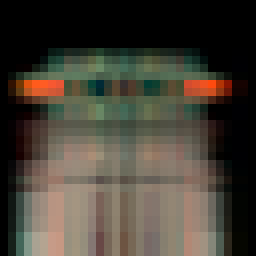

"**Image 1:** k = 5, σ₁ = 81.70531779602835, σₖ₊₁ = 5.787312696215127"


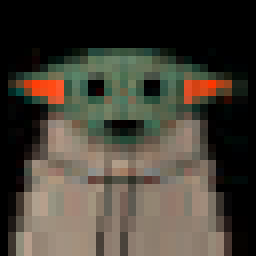

"**Image 1:** k = 10, σ₁ = 81.70531779602835, σₖ₊₁ = 3.1468748008236367"


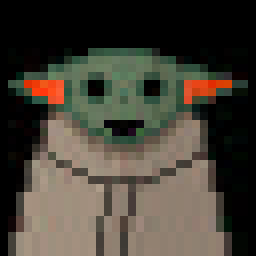

"**Image 1:** k = 50, σ₁ = 81.70531779602835, σₖ₊₁ = 6.903954296501285e-15"


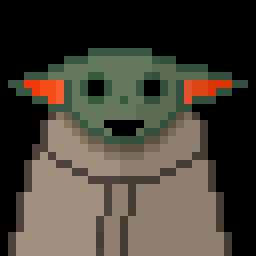

"**Image 2:** k = 2, σ₁ = 553.7646604978316, σₖ₊₁ = 64.15550959958331"


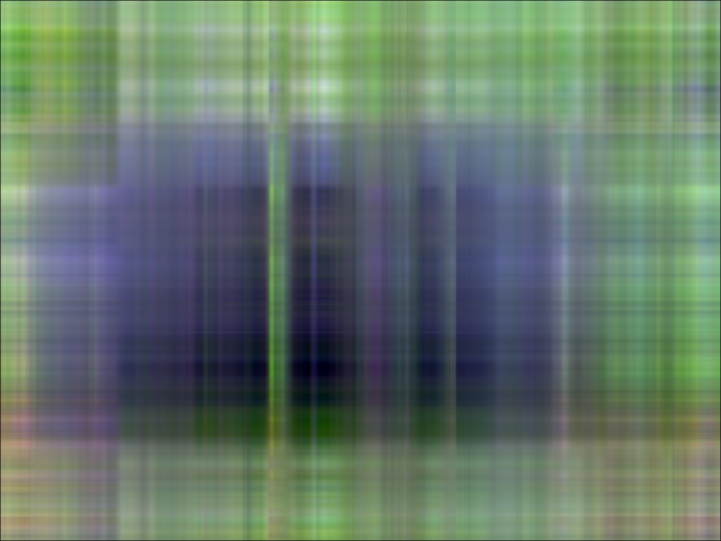

"**Image 2:** k = 5, σ₁ = 553.7646604978316, σₖ₊₁ = 48.996971536705836"


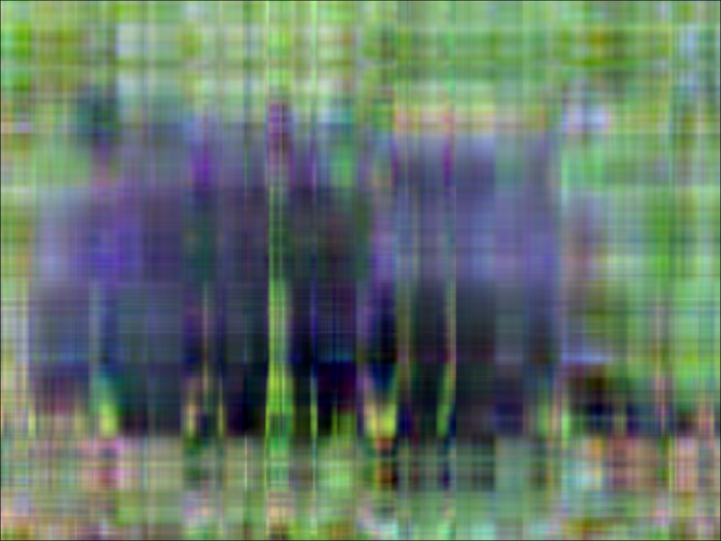

"**Image 2:** k = 10, σ₁ = 553.7646604978316, σₖ₊₁ = 33.531174912170314"


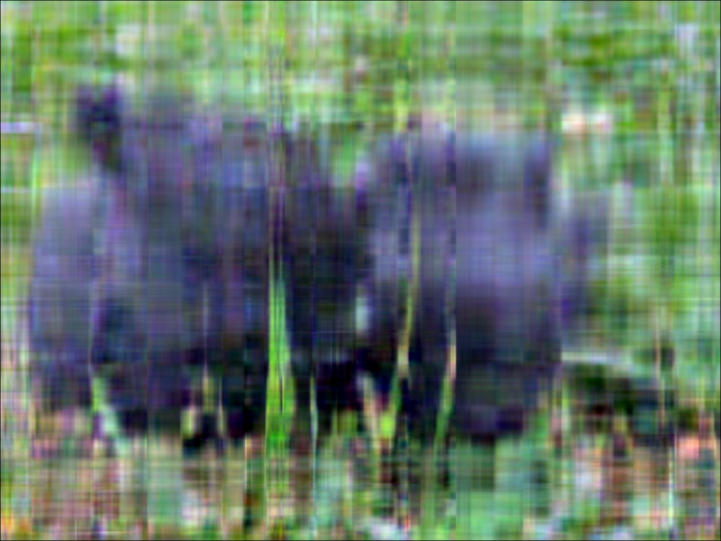

"**Image 2:** k = 50, σ₁ = 553.7646604978316, σₖ₊₁ = 11.343967805977547"


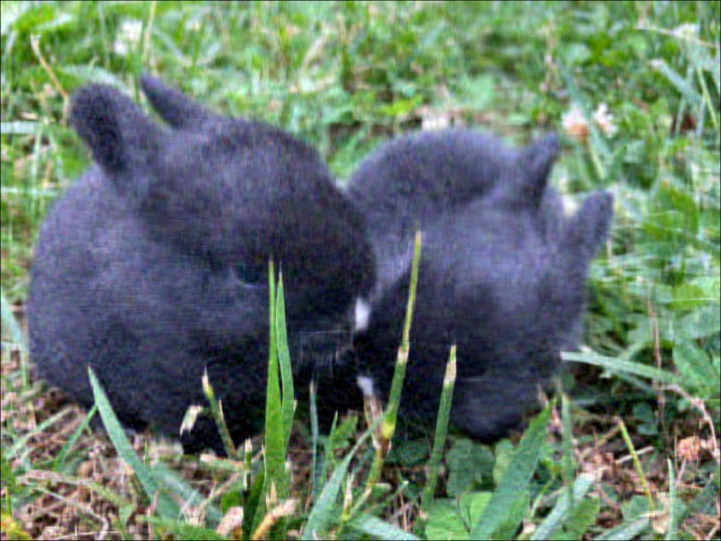

In [31]:
# show all the images side by side with their sigma values
for (k, sigma1_val, sigma1_kplus1_val) in zip(k_vals, sigma1, sigma1_kplus1)
    display(Markdown.MD("**Image 1:** k = $k, σ₁ = $sigma1_val, σₖ₊₁ = $sigma1_kplus1_val"))
    image = load("proj3_image_k_$k.png")
    display(image)
end

for (k, sigma2_val, sigma2_kplus1_val) in zip(k_vals, sigma2, sigma2_kplus1)
    display(Markdown.MD("**Image 2:** k = $k, σ₁ = $sigma2_val, σₖ₊₁ = $sigma2_kplus1_val"))
    image = load("bunny_k_$k.png")
    display(image)
end

### (e)

In [52]:
# Identify for which value of k we have σₖ₊₁ < 1 for image 1
k = 1
while true
    _, _, _, _, sigma1_kplus1_val = process_image(k, img1_R, img1_G, img1_B)
    if sigma1_kplus1_val < 1
        println("For image 1, the smallest k such that σₖ₊₁ < 1 is: $k")
        break
    end
    k += 1
end

For image 1, the smallest k such that σₖ₊₁ < 1 is: 18


"**Original Image 1:**"


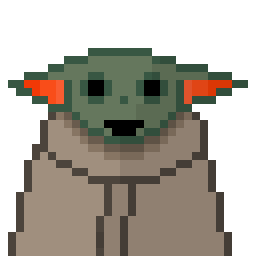

"**Rank-k Approximation for k = 18:**"


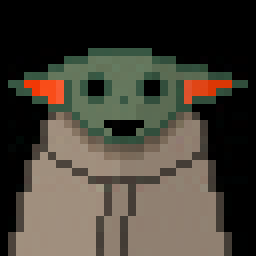

Image saved as proj3_image_k_18.png


In [53]:
# show the original image and the rank-k approximation
display(Markdown.MD("**Original Image 1:**"))
image = load(filename1)
display(image)
display(Markdown.MD("**Rank-k Approximation for k = $k:**"))
A_k1_R, A_k1_G, A_k1_B, sigma1_avg, sigma1_kplus1_avg = process_image(k, img1_R, img1_G, img1_B)
matrix_to_image(A_k1_R, A_k1_G, A_k1_B, "proj3_image_k_$k.png")
image = load("proj3_image_k_$k.png")
display(image)

In [55]:
# Identify for which value of k we have σₖ₊₁ < 1 for image 2
k = 349
while true
    _, _, _, _, sigma2_kplus1_val = process_image(k, img2_R, img2_G, img2_B)
    println("k = $k, σₖ₊₁ = $sigma2_kplus1_val")
    if sigma2_kplus1_val < 1
        println("For image 2, the smallest k such that σₖ₊₁ < 1 is: $k")
        break
    end
    k += 1
end

k = 349, σₖ₊₁ = 0.9998746606066385
For image 2, the smallest k such that σₖ₊₁ < 1 is: 349


"**Original Image 1:**"


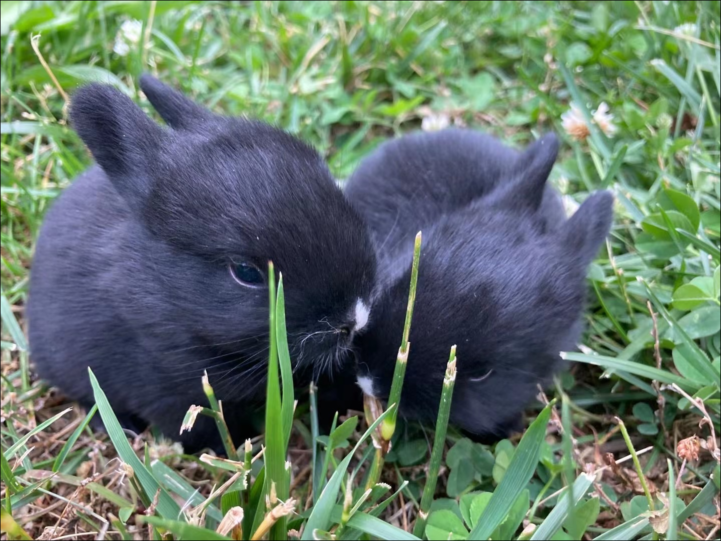

"**Rank-k Approximation for k = 349:**"


Image saved as bunny_k_349.png


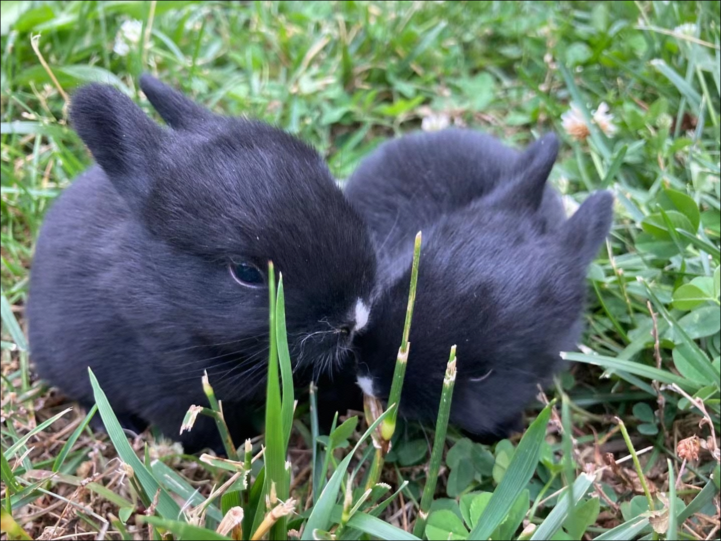

In [56]:
# show the original image and the rank-k approximation
display(Markdown.MD("**Original Image 1:**"))
image = load(filename2)
display(image)
display(Markdown.MD("**Rank-k Approximation for k = $k:**"))
A_k2_R, A_k2_G, A_k2_B, sigma2_avg, sigma2_kplus1_avg = process_image(k, img2_R, img2_G, img2_B)
matrix_to_image(A_k2_R, A_k2_G, A_k2_B, "bunny_k_$k.png")
image = load("bunny_k_$k.png")
display(image)

### (f)

Not putting my portrait in here but here's the code.

In [ ]:
myphotodir = "MyPortrait.jpg"
img3 = load_image_to_matrix(myphotodir)
img3_R, img3_G, img3_B = img3

# process images with different k values
for k in k_vals
    A_k3_R, A_k3_G, A_k3_B = process_image(k, img3_R, img3_G, img3_B)
    # show the image
    colorview(RGB, A_k3_R, A_k3_G, A_k3_B)
end